<a href="https://colab.research.google.com/github/RafaelaMlucca/skin-lesion-classification-ham10000/blob/main/03_experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto IA — HAM10000: Experimentos (v3, playground)

Pensado para **brincar com vários backbones modernos** sem reescrever nada.

- **Modelo A** (referência): DINOv2 ViT-B/14 congelado + SVM (igual à v2).
- **Modelo B** (playground): backbone definido em **uma variável** (`BACKBONE`) — troque a string para testar ConvNeXt V2, MaxViT, Swin, ViT, EfficientNetV2...
- Interruptor **`USE_MIXUP`**: liga MixUp/CutMix (+ sampler balanceado) ou usa os class weights suavizados da v2.
- Mantém: split por `lesion_id`, warmup → cosine, early stopping, TTA, métricas.

> Rodar no **Colab com GPU T4**.

## 0. Setup

In [1]:
!pip install -q timm kagglehub

In [2]:
import os, time, copy, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
import timm
from timm.data import Mixup
from timm.loss import SoftTargetCrossEntropy

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             classification_report, confusion_matrix)

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)
RESULTS_DIR = 'results'; os.makedirs(RESULTS_DIR, exist_ok=True)

Device: cuda


## 1. Dados, rótulos e caminhos

In [3]:
import kagglehub
DATA_DIR = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
df = pd.read_csv(os.path.join(DATA_DIR, 'HAM10000_metadata.csv'))
img_paths = {}
for root, _, files in os.walk(DATA_DIR):
    for f in files:
        if f.lower().endswith('.jpg'):
            img_paths[os.path.splitext(f)[0]] = os.path.join(root, f)
df['path'] = df['image_id'].map(img_paths)
df = df.dropna(subset=['path']).reset_index(drop=True)
CLASSES = sorted(df['dx'].unique().tolist())
CLASS_TO_IDX = {cl: i for i, cl in enumerate(CLASSES)}
df['label'] = df['dx'].map(CLASS_TO_IDX)
MEL_IDX = CLASS_TO_IDX['mel']
print('Imagens:', len(df), '| Classes:', CLASSES)

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Imagens: 10015 | Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


## 2. Split agrupado por `lesion_id`

In [4]:
def grouped_split(frame, seed=SEED):
    idx = np.arange(len(frame)); y = frame['label'].values; g = frame['lesion_id'].values
    sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
    trainval_pos, test_pos = next(sgkf.split(idx, y, g))
    tv = frame.iloc[trainval_pos].reset_index(drop=True)
    sgkf2 = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
    tr_pos, val_pos = next(sgkf2.split(np.arange(len(tv)), tv['label'].values, tv['lesion_id'].values))
    return (tv.iloc[tr_pos].reset_index(drop=True),
            tv.iloc[val_pos].reset_index(drop=True),
            frame.iloc[test_pos].reset_index(drop=True))

train_df, val_df, test_df = grouped_split(df)
assert not (set(train_df['lesion_id']) & set(test_df['lesion_id'])), 'VAZAMENTO!'
print(f'Treino: {len(train_df)} | Val: {len(val_df)} | Teste: {len(test_df)}')

Treino: 6409 | Val: 1592 | Teste: 2014


## 3. Transforms e Dataset

In [5]:
IMG_SIZE = 224
MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

eval_tf = T.Compose([T.Resize((IMG_SIZE, IMG_SIZE)), T.ToTensor(), T.Normalize(MEAN, STD)])
train_tf = T.Compose([
    T.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    T.RandomHorizontalFlip(), T.RandomVerticalFlip(),
    T.RandAugment(num_ops=2, magnitude=7),
    T.ToTensor(), T.Normalize(MEAN, STD),
])

class HAMDataset(Dataset):
    def __init__(self, frame, transform):
        self.frame = frame.reset_index(drop=True); self.transform = transform
    def __len__(self): return len(self.frame)
    def __getitem__(self, i):
        row = self.frame.iloc[i]
        return self.transform(Image.open(row['path']).convert('RGB')), int(row['label'])

## 4. Avaliação (com TTA)

In [6]:
def evaluate(y_true, y_pred, name):
    acc  = accuracy_score(y_true, y_pred)
    bacc = balanced_accuracy_score(y_true, y_pred)
    mf1  = f1_score(y_true, y_pred, average='macro')
    cm   = confusion_matrix(y_true, y_pred, labels=range(len(CLASSES)))
    rec_mel = cm[MEL_IDX, MEL_IDX] / cm[MEL_IDX].sum() if cm[MEL_IDX].sum() else 0.0
    print(f'\n===== {name} =====')
    print(f'Acurácia: {acc:.3f} | Balanced acc: {bacc:.3f} | Macro-F1: {mf1:.3f} | Recall melanoma: {rec_mel:.3f}')
    print(classification_report(y_true, y_pred, target_names=CLASSES, digits=3, zero_division=0))
    fig, ax = plt.subplots(figsize=(6, 5)); im = ax.imshow(cm, cmap='Blues'); fig.colorbar(im)
    ax.set_xticks(range(len(CLASSES))); ax.set_xticklabels(CLASSES, rotation=45, ha='right')
    ax.set_yticks(range(len(CLASSES))); ax.set_yticklabels(CLASSES)
    ax.set_xlabel('Predito'); ax.set_ylabel('Verdadeiro'); ax.set_title(f'Matriz de confusão — {name}')
    for i in range(len(CLASSES)):
        for j in range(len(CLASSES)):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=8)
    plt.tight_layout(); plt.savefig(os.path.join(RESULTS_DIR, f'cm_{name}.png'), dpi=120); plt.show()
    return {'modelo': name, 'acuracia': acc, 'balanced_acc': bacc, 'macro_f1': mf1, 'recall_melanoma': rec_mel}

@torch.no_grad()
def predict_loader(model, loader, tta=False):
    model.eval(); ys, ps = [], []
    for x, y in loader:
        x = x.to(device)
        with torch.amp.autocast('cuda', enabled=(device == 'cuda')):
            prob = model(x).softmax(1)
            if tta:
                prob = prob + model(torch.flip(x, dims=[3])).softmax(1)
                prob = prob + model(torch.flip(x, dims=[2])).softmax(1)
        ps.append(prob.argmax(1).cpu().numpy()); ys.append(y.numpy())
    return np.concatenate(ys), np.concatenate(ps)

## 5. Modelo A — DINOv2 ViT-B/14 + SVM (referência)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Extraindo features...
Melhor SVM (val): (0.58592353106799, 10, 0.001)

===== A_DINOv2-B_SVM =====
Acurácia: 0.805 | Balanced acc: 0.583 | Macro-F1: 0.601 | Recall melanoma: 0.536
              precision    recall  f1-score   support

       akiec      0.493     0.485     0.489        68
         bcc      0.566     0.690     0.622       100
         bkl      0.579     0.644     0.610       205
          df      0.600     0.136     0.222        22
         mel      0.541     0.536     0.538       222
          nv      0.921     0.911     0.916      1363
        vasc      1.000     0.676     0.807        34

    accuracy                          0.805      2014
   macro avg      0.671     0.583     0.601      2014
weighted avg      0.810     0.805     0.805      2014



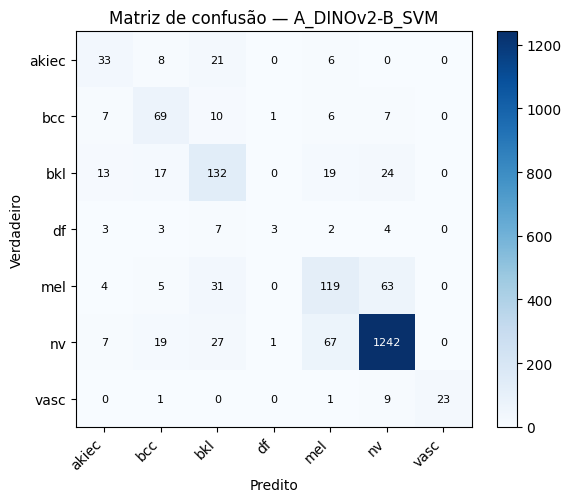

In [7]:
backbone = timm.create_model('vit_base_patch14_dinov2.lvd142m',
                             pretrained=True, num_classes=0, img_size=IMG_SIZE).eval().to(device)
for p in backbone.parameters(): p.requires_grad_(False)

@torch.no_grad()
def extract_features(frame):
    loader = DataLoader(HAMDataset(frame, eval_tf), batch_size=64, shuffle=False, num_workers=2)
    feats, labels = [], []
    for x, y in loader:
        with torch.amp.autocast('cuda', enabled=(device == 'cuda')):
            f = backbone(x.to(device))
        feats.append(f.float().cpu().numpy()); labels.append(y.numpy())
    return np.concatenate(feats), np.concatenate(labels)

print('Extraindo features...')
Xtr, ytr = extract_features(train_df); Xval, yval = extract_features(val_df); Xte, yte = extract_features(test_df)
scaler = StandardScaler().fit(Xtr)
Xtr_s, Xval_s, Xte_s = scaler.transform(Xtr), scaler.transform(Xval), scaler.transform(Xte)

best = (-1.0, None, None)
for C in [1, 10, 100]:
    for gamma in ['scale', 0.001]:
        clf = SVC(kernel='rbf', C=C, gamma=gamma, class_weight='balanced', random_state=SEED).fit(Xtr_s, ytr)
        f1v = f1_score(yval, clf.predict(Xval_s), average='macro')
        if f1v > best[0]: best = (f1v, C, gamma)
print('Melhor SVM (val):', best)
Xtrv = np.vstack([Xtr_s, Xval_s]); ytrv = np.concatenate([ytr, yval])
svm = SVC(kernel='rbf', C=best[1], gamma=best[2], class_weight='balanced', random_state=SEED).fit(Xtrv, ytrv)
res_A = evaluate(yte, svm.predict(Xte_s), 'A_DINOv2-B_SVM')

## 6. Modelo B — PLAYGROUND

**Troque o `BACKBONE` e rode as células 6.x novamente** para comparar arquiteturas.

In [8]:
# ============ ESCOLHA AQUI ============
BACKBONES = [
    'convnextv2_tiny.fcmae_ft_in22k_in1k',           # ConvNeXt V2
    'maxvit_tiny_tf_224.in1k',                        # híbrido conv+atenção
    'tf_efficientnetv2_s.in21k_ft_in1k',              # o da v2
    'convnext_tiny.in12k_ft_in1k',                    # ConvNeXt v1
    'swin_tiny_patch4_window7_224.ms_in22k_ft_in1k',  # Swin
    'vit_base_patch16_224.augreg2_in21k_ft_in1k',     # ViT
]
USE_MIXUP = True
# ======================================

BATCH = 32; WARMUP = 2; EPOCHS = 20; LR_HEAD = 1e-3; LR_FULL = 1e-4; PATIENCE = 4

val_loader  = DataLoader(HAMDataset(val_df, eval_tf),  batch_size=BATCH, shuffle=False, num_workers=2)
test_loader = DataLoader(HAMDataset(test_df, eval_tf), batch_size=BATCH, shuffle=False, num_workers=2)

# Treino/loss independem do backbone -> montados uma única vez
counts = train_df['label'].value_counts().sort_index().values
if USE_MIXUP:
    inv = 1.0 / counts
    sample_w = inv[train_df['label'].values]
    sampler = WeightedRandomSampler(torch.as_tensor(sample_w, dtype=torch.double),
                                    num_samples=len(train_df), replacement=True)
    train_loader = DataLoader(HAMDataset(train_df, train_tf), batch_size=BATCH,
                              sampler=sampler, num_workers=2, drop_last=True)
    mixup_fn = Mixup(mixup_alpha=0.2, cutmix_alpha=1.0, prob=0.5, switch_prob=0.5,
                     mode='batch', label_smoothing=0.05, num_classes=len(CLASSES))
    criterion = SoftTargetCrossEntropy()
    print('Treino: MixUp/CutMix + WeightedRandomSampler')
else:
    w = (counts.sum() / (len(counts) * counts)) ** 0.5
    class_w = torch.tensor(w / w.mean(), dtype=torch.float32).to(device)
    train_loader = DataLoader(HAMDataset(train_df, train_tf), batch_size=BATCH,
                              shuffle=True, num_workers=2)
    mixup_fn = None
    criterion = nn.CrossEntropyLoss(weight=class_w, label_smoothing=0.05)
    print('Treino: class weights suavizados')

scaler_amp = torch.amp.GradScaler('cuda', enabled=(device == 'cuda'))
print(f'{len(BACKBONES)} backbones na fila | MixUp: {USE_MIXUP}')

Treino: MixUp/CutMix + WeightedRandomSampler
6 backbones na fila | MixUp: True


In [9]:
def run_epoch(model, loader, optimizer):
    model.train(); total = 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        if mixup_fn is not None:
            x, y = mixup_fn(x, y)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda', enabled=(device == 'cuda')):
            loss = criterion(model(x), y)
        scaler_amp.scale(loss).backward(); scaler_amp.step(optimizer); scaler_amp.update()
        total += loss.item() * x.size(0)
    return total / len(loader.dataset)

def val_macro_f1(model):
    yv, pv = predict_loader(model, val_loader, tta=False)
    return f1_score(yv, pv, average='macro')

def train_one_model(backbone_name):
    model = timm.create_model(backbone_name, pretrained=True, num_classes=len(CLASSES)).to(device)
    best_f1, best_state, no_improve = -1.0, None, 0

    # Fase 1: warmup (só a cabeça)
    for p in model.parameters(): p.requires_grad_(False)
    for p in model.get_classifier().parameters(): p.requires_grad_(True)
    opt = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=LR_HEAD)
    for _ in range(WARMUP):
        run_epoch(model, train_loader, opt); vf1 = val_macro_f1(model)
        if vf1 > best_f1: best_f1, best_state = vf1, copy.deepcopy(model.state_dict())

    # Fase 2: fine-tuning completo + cosine
    for p in model.parameters(): p.requires_grad_(True)
    opt = torch.optim.AdamW(model.parameters(), lr=LR_FULL, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS - WARMUP)
    for epoch in range(WARMUP, EPOCHS):
        run_epoch(model, train_loader, opt); vf1 = val_macro_f1(model); sched.step()
        print(f'  [{epoch+1}/{EPOCHS}] val macro-F1 {vf1:.3f} | lr {sched.get_last_lr()[0]:.2e}')
        if vf1 > best_f1:
            best_f1, best_state, no_improve = vf1, copy.deepcopy(model.state_dict()), 0
        else:
            no_improve += 1
            if no_improve >= PATIENCE:
                print(f'  early stopping'); break

    model.load_state_dict(best_state)
    return model, best_f1


========== B_convnextv2_tiny_mixup ==========


model.safetensors:   0%|          | 0.00/115M [00:00<?, ?B/s]

  [3/20] val macro-F1 0.648 | lr 9.92e-05
  [4/20] val macro-F1 0.673 | lr 9.70e-05
  [5/20] val macro-F1 0.677 | lr 9.33e-05
  [6/20] val macro-F1 0.707 | lr 8.83e-05
  [7/20] val macro-F1 0.685 | lr 8.21e-05
  [8/20] val macro-F1 0.701 | lr 7.50e-05
  [9/20] val macro-F1 0.733 | lr 6.71e-05
  [10/20] val macro-F1 0.730 | lr 5.87e-05
  [11/20] val macro-F1 0.740 | lr 5.00e-05
  [12/20] val macro-F1 0.760 | lr 4.13e-05
  [13/20] val macro-F1 0.767 | lr 3.29e-05
  [14/20] val macro-F1 0.749 | lr 2.50e-05
  [15/20] val macro-F1 0.759 | lr 1.79e-05
  [16/20] val macro-F1 0.764 | lr 1.17e-05
  [17/20] val macro-F1 0.758 | lr 6.70e-06
  early stopping
Melhor val macro-F1: 0.767 | tempo 27.4 min

===== B_convnextv2_tiny_mixup =====
Acurácia: 0.811 | Balanced acc: 0.722 | Macro-F1: 0.713 | Recall melanoma: 0.748
              precision    recall  f1-score   support

       akiec      0.581     0.735     0.649        68
         bcc      0.760     0.730     0.745       100
         bkl      0.

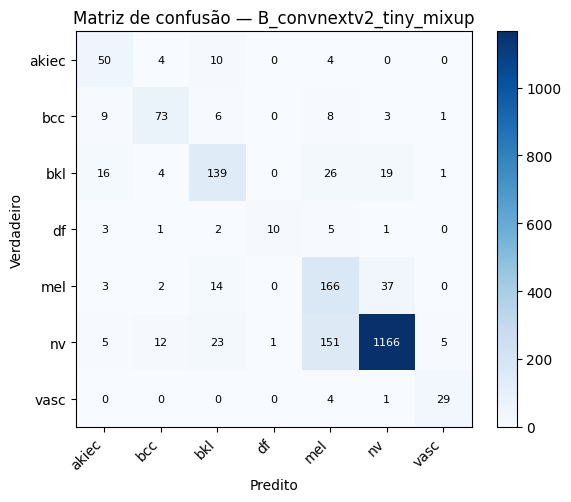


========== B_maxvit_tiny_tf_224_mixup ==========


model.safetensors:   0%|          | 0.00/124M [00:00<?, ?B/s]

  [3/20] val macro-F1 0.677 | lr 9.92e-05
  [4/20] val macro-F1 0.656 | lr 9.70e-05
  [5/20] val macro-F1 0.642 | lr 9.33e-05
  [6/20] val macro-F1 0.667 | lr 8.83e-05
  [7/20] val macro-F1 0.672 | lr 8.21e-05
  early stopping
Melhor val macro-F1: 0.677 | tempo 11.5 min

===== B_maxvit_tiny_tf_224_mixup =====
Acurácia: 0.785 | Balanced acc: 0.658 | Macro-F1: 0.628 | Recall melanoma: 0.495
              precision    recall  f1-score   support

       akiec      0.388     0.735     0.508        68
         bcc      0.667     0.760     0.710       100
         bkl      0.480     0.634     0.546       205
          df      0.700     0.318     0.438        22
         mel      0.550     0.495     0.521       222
          nv      0.942     0.866     0.903      1363
        vasc      0.750     0.794     0.771        34

    accuracy                          0.785      2014
   macro avg      0.639     0.658     0.628      2014
weighted avg      0.813     0.785     0.794      2014



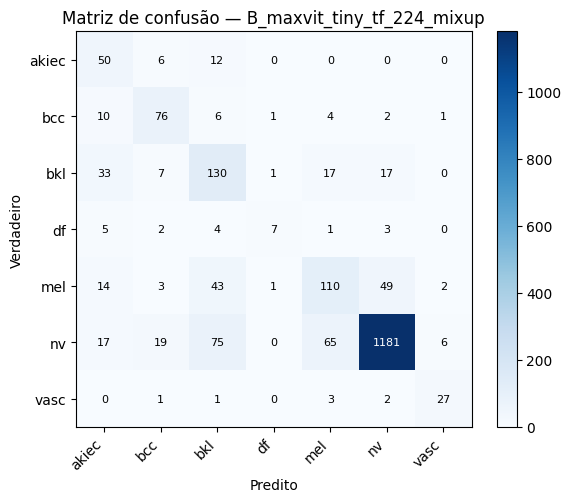


========== B_tf_efficientnetv2_s_mixup ==========


model.safetensors:   0%|          | 0.00/86.5M [00:00<?, ?B/s]

  [3/20] val macro-F1 0.485 | lr 9.92e-05
  [4/20] val macro-F1 0.578 | lr 9.70e-05
  [5/20] val macro-F1 0.592 | lr 9.33e-05
  [6/20] val macro-F1 0.611 | lr 8.83e-05
  [7/20] val macro-F1 0.643 | lr 8.21e-05
  [8/20] val macro-F1 0.707 | lr 7.50e-05
  [9/20] val macro-F1 0.690 | lr 6.71e-05
  [10/20] val macro-F1 0.686 | lr 5.87e-05
  [11/20] val macro-F1 0.688 | lr 5.00e-05
  [12/20] val macro-F1 0.692 | lr 4.13e-05
  early stopping
Melhor val macro-F1: 0.707 | tempo 16.9 min

===== B_tf_efficientnetv2_s_mixup =====
Acurácia: 0.822 | Balanced acc: 0.738 | Macro-F1: 0.720 | Recall melanoma: 0.644
              precision    recall  f1-score   support

       akiec      0.616     0.662     0.638        68
         bcc      0.738     0.760     0.749       100
         bkl      0.641     0.698     0.668       205
          df      0.778     0.636     0.700        22
         mel      0.534     0.644     0.584       222
          nv      0.936     0.883     0.909      1363
        vasc   

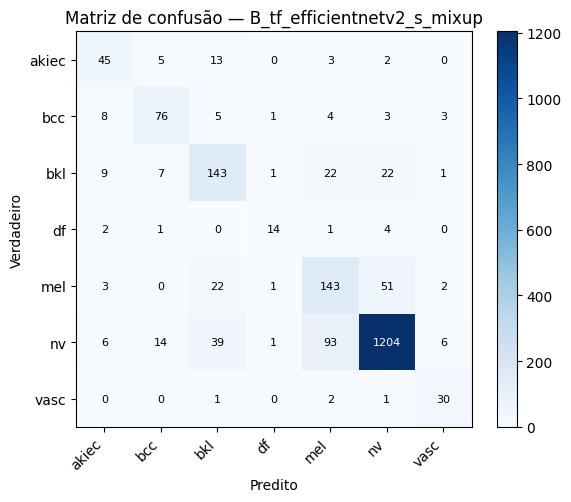


========== B_convnext_tiny_mixup ==========


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

  [3/20] val macro-F1 0.607 | lr 9.92e-05
  [4/20] val macro-F1 0.627 | lr 9.70e-05
  [5/20] val macro-F1 0.602 | lr 9.33e-05
  [6/20] val macro-F1 0.676 | lr 8.83e-05
  [7/20] val macro-F1 0.667 | lr 8.21e-05
  [8/20] val macro-F1 0.728 | lr 7.50e-05
  [9/20] val macro-F1 0.699 | lr 6.71e-05
  [10/20] val macro-F1 0.686 | lr 5.87e-05
  [11/20] val macro-F1 0.743 | lr 5.00e-05
  [12/20] val macro-F1 0.726 | lr 4.13e-05
  [13/20] val macro-F1 0.754 | lr 3.29e-05
  [14/20] val macro-F1 0.749 | lr 2.50e-05
  [15/20] val macro-F1 0.741 | lr 1.79e-05
  [16/20] val macro-F1 0.765 | lr 1.17e-05
  [17/20] val macro-F1 0.754 | lr 6.70e-06
  [18/20] val macro-F1 0.753 | lr 3.02e-06
  [19/20] val macro-F1 0.760 | lr 7.60e-07
  [20/20] val macro-F1 0.759 | lr 0.00e+00
  early stopping
Melhor val macro-F1: 0.765 | tempo 26.6 min

===== B_convnext_tiny_mixup =====
Acurácia: 0.825 | Balanced acc: 0.712 | Macro-F1: 0.710 | Recall melanoma: 0.680
              precision    recall  f1-score   support

 

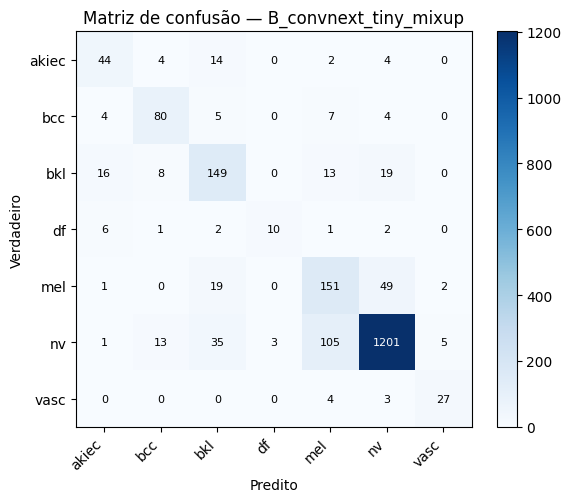


========== B_swin_tiny_patch4_window7_224_mixup ==========


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

  [3/20] val macro-F1 0.655 | lr 9.92e-05
  [4/20] val macro-F1 0.641 | lr 9.70e-05
  [5/20] val macro-F1 0.703 | lr 9.33e-05
  [6/20] val macro-F1 0.686 | lr 8.83e-05
  [7/20] val macro-F1 0.712 | lr 8.21e-05
  [8/20] val macro-F1 0.733 | lr 7.50e-05
  [9/20] val macro-F1 0.743 | lr 6.71e-05
  [10/20] val macro-F1 0.723 | lr 5.87e-05
  [11/20] val macro-F1 0.751 | lr 5.00e-05
  [12/20] val macro-F1 0.748 | lr 4.13e-05
  [13/20] val macro-F1 0.764 | lr 3.29e-05
  [14/20] val macro-F1 0.757 | lr 2.50e-05
  [15/20] val macro-F1 0.763 | lr 1.79e-05
  [16/20] val macro-F1 0.779 | lr 1.17e-05
  [17/20] val macro-F1 0.779 | lr 6.70e-06
  [18/20] val macro-F1 0.784 | lr 3.02e-06
  [19/20] val macro-F1 0.780 | lr 7.60e-07
  [20/20] val macro-F1 0.778 | lr 0.00e+00
Melhor val macro-F1: 0.784 | tempo 27.8 min

===== B_swin_tiny_patch4_window7_224_mixup =====
Acurácia: 0.835 | Balanced acc: 0.713 | Macro-F1: 0.716 | Recall melanoma: 0.734
              precision    recall  f1-score   support

   

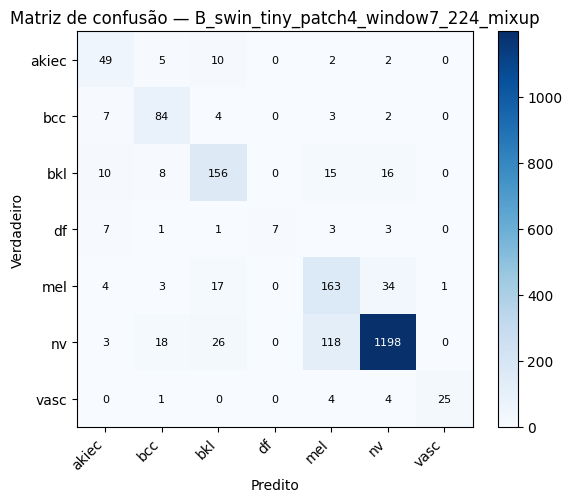


========== B_vit_base_patch16_224_mixup ==========


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

  [3/20] val macro-F1 0.598 | lr 9.92e-05
  [4/20] val macro-F1 0.619 | lr 9.70e-05
  [5/20] val macro-F1 0.695 | lr 9.33e-05
  [6/20] val macro-F1 0.646 | lr 8.83e-05


In [ ]:
import gc
if 'runs' not in globals():
    runs = {}

for backbone_name in BACKBONES:
    run_name = 'B_' + backbone_name.split('.')[0] + ('_mixup' if USE_MIXUP else '')
    print(f'\n========== {run_name} ==========')
    t0 = time.time()
    model_b, best_f1 = train_one_model(backbone_name)
    print(f'Melhor val macro-F1: {best_f1:.3f} | tempo {(time.time()-t0)/60:.1f} min')

    yte_b, pred_te_B = predict_loader(model_b, test_loader, tta=True)
    runs[run_name] = evaluate(yte_b, pred_te_B, run_name)   # salva por modelo

    del model_b; gc.collect(); torch.cuda.empty_cache()      # libera a GPU p/ o próximo

print('\nRodadas salvas:', list(runs.keys()))

## 7. Comparação

In [ ]:
comp = pd.DataFrame([res_A, res_B]).set_index('modelo').round(3)
print(comp)
comp[['acuracia', 'balanced_acc', 'macro_f1', 'recall_melanoma']].plot(kind='bar', figsize=(9, 5))
plt.title('v3 — A (DINOv2-B + SVM) vs ' + RUN_NAME)
plt.ylabel('métrica'); plt.xticks(rotation=0); plt.ylim(0, 1); plt.legend(loc='lower right')
plt.tight_layout(); plt.show()

## 8. Como brincar

- **Trocar de backbone:** mude `BACKBONE` na célula 6.0 e re-execute as células 6.x e 7. O `RUN_NAME` muda sozinho (vira o nome no gráfico e na matriz de confusão).
- **MixUp on/off:** `USE_MIXUP` alterna entre MixUp/CutMix (com sampler balanceado) e os class weights suavizados.
- **Comparar vários:** guarde o `res_B` de cada rodada numa lista (ex.: `runs.append(res_B)`) e monte uma tabela com todos no final.
- **Atenção:** backbones que pedem outra resolução (ex.: `swinv2_*_256`) exigem mudar `IMG_SIZE` lá em cima — os listados aqui já são todos de 224.